# ISM-CyberRAG - Sprint 2 Development

**Advanced RAG pipeline** for the Australian Information Security Manual.

Pipeline: Parse ISM PDFs > ISM-Aware Chunking > Embed > Store in Supabase pgvector > Hybrid Retrieval > Cross-Encoder Reranking > Generate Answer > Evaluate (RAGAS) > Log (ClearML)

---

**Team Name:** Studio Builders

**Team Members:**

- Sreekar Reddy Edulapalli (25617806)
- Chandan Sreenivasaiah (25674250)
- Ruben Easo Thomas (25598184)

## 0 - Sprint 2 Objectives

In this sprint we move from a baseline RAG pipeline to an improved system with three changes:

1. **ISM-Aware Chunking**: Replace fixed-size character splitting with a parser that detects ISM control boundaries (`Control: ISM-XXXX`). Each chunk maps to a single control (or a group of related controls) with structured metadata: control ID, category, applicability levels, Essential 8 mapping and revision number.

2. **Hybrid Search with RRF**: Combine pgvector cosine similarity with PostgreSQL full-text search (BM25). Reciprocal Rank Fusion merges both ranked lists so that queries with exact control IDs or technical terms get better results alongside semantic matches.

3. **Cross-Encoder Reranking**: After hybrid search returns the top 10 candidates, a cross-encoder (`ms-marco-MiniLM-L-6-v2`) re-scores each chunk against the query. The top 5 reranked chunks go to the LLM, improving context precision.

We compare RAGAS scores against the Sprint 1 baseline to measure impact.

## 1 - Environment Setup

In [9]:
import os
import sys

# When running in Colab, clone the repo and install dependencies
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.exists("ism-cyberrag"):
        !git clone https://github.com/studiobuilders/ism-cyberrag.git
    os.chdir("ism-cyberrag")
    !pip install -q -r requirements.txt

# Add project root to path (works from notebooks/ folder or project root)
notebook_dir = os.path.abspath("")
if notebook_dir.endswith("notebooks"):
    project_root = os.path.dirname(notebook_dir)
else:
    project_root = notebook_dir

if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Load environment variables
from dotenv import load_dotenv
load_dotenv(os.path.join(project_root, ".env"))

# If running in Colab, prompt for secrets that aren't in .env
if IN_COLAB:
    from getpass import getpass
    if not os.getenv("GROQ_API_KEY"):
        os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")
    if not os.getenv("SUPABASE_URL"):
        os.environ["SUPABASE_URL"] = getpass("Enter your Supabase URL: ")
    if not os.getenv("SUPABASE_PUBLISHABLE_KEY"):
        os.environ["SUPABASE_PUBLISHABLE_KEY"] = getpass("Enter your Supabase anon key: ")


print(f"Project root: {project_root}")
print(f"Running in Colab: {IN_COLAB}")


Project root: /Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag
Running in Colab: False


## 2 - ClearML Initialization

In [10]:
# ── Initialize ClearML to track Sprint 2 experiments ──
from src.config import CLEARML_PROJECT, CLEARML_TASK
from clearml import Task
from datetime import datetime

# Add a dynamic timestamp so every run is logged as a separate experiment
dynamic_task_name = f"{CLEARML_TASK} [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]"

task = Task.init(
    project_name=CLEARML_PROJECT,
    task_name=dynamic_task_name,
    task_type=Task.TaskTypes.data_processing,
    reuse_last_task_id=False,
)
print(f"ClearML task created: {CLEARML_PROJECT} / {dynamic_task_name}")
print(f"View at: https://app.clear.ml")

ClearML Task: created new task id=379669d5c8ca47d083bce53ab9b815fc


Could not fetch GPU stats: NVML Shared Library Not Found


ClearML results page: https://app.clear.ml/projects/8cc0565844234597add9563254af0f2e/experiments/379669d5c8ca47d083bce53ab9b815fc/output/log
ClearML task created: ISM-CyberRAG / Sprint 2 - ISM-Aware Chunking + Hybrid Search + Reranking [2026-04-10 09:25:36]
View at: https://app.clear.ml


## 3 - Initialize Clients and Models

In [11]:
from src.supabase_utils import get_supabase_client, count_rows
from src.embeddings import load_embedding_model, embed_texts, embed_query
from src.reranking import load_reranker
from src.config import (
    EMBEDDING_MODEL_NAME, RERANKER_MODEL, LLM_PROVIDER, LLM_MODEL_NAME,
    CHUNK_MIN_WORDS, CHUNK_MAX_WORDS, INITIAL_RETRIEVE_COUNT, RERANK_TOP_K, RRF_K,
)

# Initialize Supabase client
supabase = get_supabase_client()
print(f"Supabase connected. Current chunks: {count_rows(supabase)}")

# Load embedding model
embed_model = load_embedding_model()
print(f"Embedding model loaded: {EMBEDDING_MODEL_NAME}")

# Load cross-encoder reranker
reranker = load_reranker()
print(f"Reranker loaded: {RERANKER_MODEL}")

print(f"\nLLM: {LLM_PROVIDER} / {LLM_MODEL_NAME}")
print(f"Chunking: min_words={CHUNK_MIN_WORDS}, max_words={CHUNK_MAX_WORDS}")
print(f"Retrieval: hybrid search (top {INITIAL_RETRIEVE_COUNT}) then rerank (top {RERANK_TOP_K})")
print(f"RRF constant: k={RRF_K}")

Supabase connected. Current chunks: 0
ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


<All keys matched successfully>


Embedding model loaded: nomic-ai/nomic-embed-text-v1.5
Reranker loaded: cross-encoder/ms-marco-MiniLM-L-6-v2

LLM: groq / llama-3.1-8b-instant
Chunking: min_words=100, max_words=800
Retrieval: hybrid search (top 10) then rerank (top 5)
RRF constant: k=50


## 4 - Data Ingestion Pipeline (ISM-Aware)

This section replaces the Sprint 1 fixed-size chunking with ISM-aware chunking. The new chunker:
- Detects control boundaries using the `Control: ISM-XXXX; Revision: N; ...` pattern
- Extracts structured metadata (control_id, applicability, essential_8, revision)
- Keeps narrative context attached to its nearest control
- Merges small chunks (< 100 words) and splits large ones (> 800 words)

**Important:** Running this section clears all existing chunks and re-ingests with the new chunker. Only run this when you want to rebuild the index.

In [12]:
from src.parse_pdf import parse_all_pdfs
from src.chunking import chunk_ism_document
from src.supabase_utils import clear_all_data, upsert_document, insert_chunks
from src.config import DATA_DIR, CHUNK_MIN_WORDS, CHUNK_MAX_WORDS

# Step 1: Parse all 25 ISM PDFs
print("Parsing ISM PDFs...")
documents = parse_all_pdfs(DATA_DIR)

# Step 2: ISM-aware chunking with metadata extraction
print("\nChunking with ISM-aware parser...")
all_chunks = []
for doc in documents:
    doc_chunks = chunk_ism_document(
        text=doc["text"],
        source_file=doc["source_file"],
        min_words=CHUNK_MIN_WORDS,
        max_words=CHUNK_MAX_WORDS,
    )
    all_chunks.extend(doc_chunks)
    controls_found = sum(1 for c in doc_chunks if c["control_id"])
    print(f"  {doc['source_file']}: {len(doc_chunks)} chunks ({controls_found} with control IDs)")

print(f"\nTotal chunks: {len(all_chunks)}")
print(f"Chunks with control IDs: {sum(1 for c in all_chunks if c['control_id'])}")
print(f"Chunks with Essential 8 mapping: {sum(1 for c in all_chunks if c['essential_8'])}")

Parsing ISM PDFs...
  Parsed 01. ISM - Using the Information security manual (December 2025).pdf (14,743 chars)
  Parsed 02. ISM - Cyber security principles (December 2025).pdf (8,938 chars)
  Parsed 03. ISM - Guidelines for cyber security roles (December 2025).pdf (26,004 chars)
  Parsed 04. ISM - Guidelines for cyber security incidents (December 2025).pdf (22,309 chars)
  Parsed 05. ISM - Guidelines for procurement and outsourcing (December 2025).pdf (26,317 chars)
  Parsed 06. ISM - Guidelines for cyber security documentation (December 2025).pdf (22,050 chars)
  Parsed 07. ISM - Guidelines for physical security (December 2025).pdf (13,677 chars)
  Parsed 08. ISM - Guidelines for personnel security (December 2025).pdf (30,434 chars)
  Parsed 09. ISM - Guidelines for communications infrastructure (September 2025).pdf (25,539 chars)
  Parsed 10. ISM - Guidelines for communications systems (December 2025).pdf (18,484 chars)
  Parsed 11. ISM - Guidelines for enterprise mobility (December

In [13]:
# Step 3: Embed all chunks
print("Generating embeddings...")
chunk_texts = [c["content"] for c in all_chunks]
embeddings = embed_texts(embed_model, chunk_texts)
print(f"Generated {len(embeddings)} embeddings (dim={len(embeddings[0])})")

# Step 4: Clear old data and ingest into Supabase
print("\nClearing old Sprint 1 data from Supabase...")
clear_all_data(supabase)

# Insert documents and capture IDs for linking
print("Inserting documents...")
doc_id_map = {}  # source_file -> document_id
for doc in documents:
    resp = upsert_document(supabase, {
        "title": doc["title"],
        "source_file": doc["source_file"],
        "content": doc["text"][:5000],  # store first 5k chars as preview
    })
    doc_id_map[doc["source_file"]] = resp.data[0]["id"]
print(f"  Inserted {len(doc_id_map)} documents")

# Insert chunks with embeddings, metadata, and document_id linkage
print("Inserting chunks with embeddings and metadata...")
BATCH_SIZE = 50
for i in range(0, len(all_chunks), BATCH_SIZE):
    batch = []
    for j in range(i, min(i + BATCH_SIZE, len(all_chunks))):
        chunk = all_chunks[j]
        batch.append({
            "content": chunk["content"],
            "document_id": doc_id_map.get(chunk.get("source_file", ""), None),
            "control_id": chunk["control_id"],
            "category": chunk["category"],
            "sub_topic": chunk["sub_topic"],
            "applicability": chunk["applicability"],
            "essential_8": chunk["essential_8"],
            "revision": chunk["revision"],
            "embedding": embeddings[j],
        })
    insert_chunks(supabase, batch)
    print(f"  Inserted batch {i // BATCH_SIZE + 1}/{(len(all_chunks) + BATCH_SIZE - 1) // BATCH_SIZE}")

final_count = count_rows(supabase)
print(f"\nDone. Total chunks in Supabase: {final_count}")

Generating embeddings...


Batches:   0%|          | 0/21 [00:00<?, ?it/s]

Generated 643 embeddings (dim=768)

Clearing old Sprint 1 data from Supabase...
All data cleared from Supabase.
Inserting documents...
  Inserted 25 documents
Inserting chunks with embeddings and metadata...
  Inserted batch 1/13
  Inserted batch 2/13
  Inserted batch 3/13
  Inserted batch 4/13
  Inserted batch 5/13
  Inserted batch 6/13
  Inserted batch 7/13
  Inserted batch 8/13
  Inserted batch 9/13
  Inserted batch 10/13
  Inserted batch 11/13
  Inserted batch 12/13
  Inserted batch 13/13

Done. Total chunks in Supabase: 643


### 4.3 - Chunking Statistics

Analyse the output of the ISM-aware chunker: chunk size distribution, metadata coverage and per-document breakdown. These stats help verify the chunker is working correctly and provide data for the Sprint 2 progress report.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Build a DataFrame of all chunks for analysis
chunk_df = pd.DataFrame(all_chunks)
chunk_df["word_count"] = chunk_df["content"].apply(lambda x: len(x.split()))
chunk_df["has_control"] = chunk_df["control_id"].notna()
chunk_df["has_essential8"] = chunk_df["essential_8"].notna()

# Overall summary
print("=== Chunking Summary ===")
print(f"Total chunks:              {len(chunk_df)}")
print(f"Chunks with control ID:    {chunk_df['has_control'].sum()} ({chunk_df['has_control'].mean():.1%})")
print(f"Chunks with Essential 8:   {chunk_df['has_essential8'].sum()} ({chunk_df['has_essential8'].mean():.1%})")
print(f"Unique control IDs:        {chunk_df['control_id'].nunique()}")
print(f"Categories found:          {chunk_df['category'].nunique()}")
print(f"\nWord count stats:")
print(chunk_df["word_count"].describe().round(1).to_string())

# Compare with Sprint 1
print(f"\nSprint 1: 900 fixed-size chunks (1000 chars, 200 overlap)")
print(f"Sprint 2: {len(chunk_df)} ISM-aware chunks (min {CHUNK_MIN_WORDS}, max {CHUNK_MAX_WORDS} words)")

=== Chunking Summary ===
Total chunks:              643
Chunks with control ID:    613 (95.3%)
Chunks with Essential 8:   65 (10.1%)
Unique control IDs:        611
Categories found:          25

Word count stats:
count    643.0
mean     169.7
std      139.9
min       51.0
25%       84.5
50%      130.0
75%      192.5
max      814.0

Sprint 1: 900 fixed-size chunks (1000 chars, 200 overlap)
Sprint 2: 643 ISM-aware chunks (min 100, max 800 words)


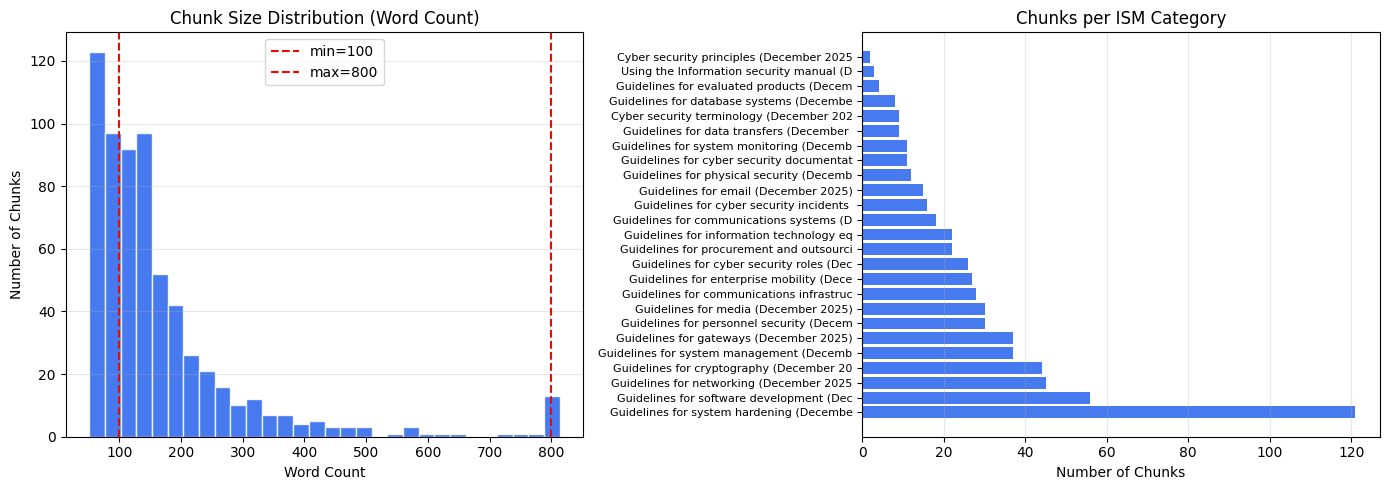

Saved chunk analysis to evaluations/sprint2_chunk_analysis.png


In [15]:
# ── Chunk size distribution histogram ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution
axes[0].hist(chunk_df["word_count"], bins=30, color="#2563eb", edgecolor="white", alpha=0.85)
axes[0].axvline(CHUNK_MIN_WORDS, color="red", linestyle="--", label=f"min={CHUNK_MIN_WORDS}")
axes[0].axvline(CHUNK_MAX_WORDS, color="red", linestyle="--", label=f"max={CHUNK_MAX_WORDS}")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Number of Chunks")
axes[0].set_title("Chunk Size Distribution (Word Count)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Per-category chunk count
cat_counts = chunk_df["category"].value_counts()
axes[1].barh(range(len(cat_counts)), cat_counts.values, color="#2563eb", alpha=0.85)
axes[1].set_yticks(range(len(cat_counts)))
axes[1].set_yticklabels([c[:40] for c in cat_counts.index], fontsize=8)
axes[1].set_xlabel("Number of Chunks")
axes[1].set_title("Chunks per ISM Category")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(project_root, "evaluations", "sprint2_chunk_analysis.png"), dpi=150)
plt.show()
print("Saved chunk analysis to evaluations/sprint2_chunk_analysis.png")

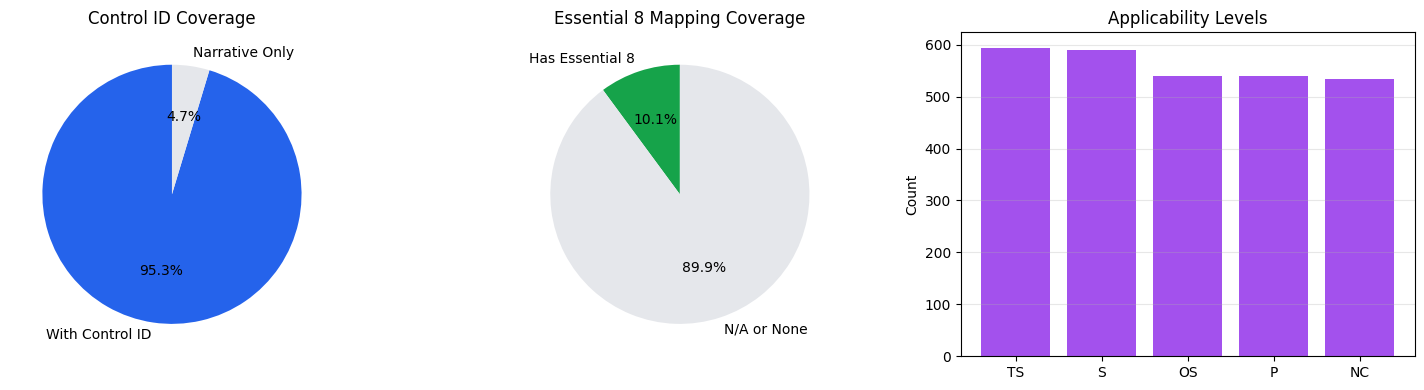

Saved metadata coverage to evaluations/sprint2_metadata_coverage.png


In [16]:
# ── Metadata coverage breakdown ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Control ID coverage (pie)
ctrl_counts = [chunk_df["has_control"].sum(), (~chunk_df["has_control"]).sum()]
axes[0].pie(ctrl_counts, labels=["With Control ID", "Narrative Only"],
            autopct="%1.1f%%", colors=["#2563eb", "#e5e7eb"], startangle=90)
axes[0].set_title("Control ID Coverage")

# Essential 8 coverage (pie)
e8_counts = [chunk_df["has_essential8"].sum(), (~chunk_df["has_essential8"]).sum()]
axes[1].pie(e8_counts, labels=["Has Essential 8", "N/A or None"],
            autopct="%1.1f%%", colors=["#16a34a", "#e5e7eb"], startangle=90)
axes[1].set_title("Essential 8 Mapping Coverage")

# Applicability level distribution
all_applicability = []
for apps in chunk_df["applicability"].dropna():
    if isinstance(apps, list):
        all_applicability.extend(apps)
if all_applicability:
    app_series = pd.Series(all_applicability).value_counts()
    axes[2].bar(app_series.index, app_series.values, color="#9333ea", alpha=0.85)
    axes[2].set_ylabel("Count")
    axes[2].set_title("Applicability Levels")
    axes[2].grid(axis="y", alpha=0.3)
else:
    axes[2].text(0.5, 0.5, "No applicability data", ha="center", va="center")
    axes[2].set_title("Applicability Levels")

plt.tight_layout()
plt.savefig(os.path.join(project_root, "evaluations", "sprint2_metadata_coverage.png"), dpi=150)
plt.show()
print("Saved metadata coverage to evaluations/sprint2_metadata_coverage.png")

## 5 - Hybrid Retrieval and Reranking

The Sprint 2 retrieval pipeline:
1. **Hybrid search**: The Supabase `hybrid_search()` RPC runs both vector cosine similarity and BM25 full-text search, then merges results using Reciprocal Rank Fusion (RRF). This returns the top 10 candidates.
2. **Cross-encoder reranking**: The `ms-marco-MiniLM-L-6-v2` cross-encoder scores each (query, chunk) pair. The top 5 reranked chunks become the LLM context.

Let's test with a sample query to verify the pipeline works.

In [17]:
from src.retrieval import hybrid_search
from src.reranking import rerank
from src.config import INITIAL_RETRIEVE_COUNT, RERANK_TOP_K

test_query = "What are the requirements for using encryption in the ISM?"

# Step 1: Embed the query
query_embedding = embed_query(embed_model, test_query)

# Step 2: Hybrid search (vector + BM25 with RRF)
raw_results = hybrid_search(supabase, test_query, query_embedding, match_count=INITIAL_RETRIEVE_COUNT)
print(f"Hybrid search returned {len(raw_results)} candidates\n")

# Show top 5 before reranking
print("--- Before Reranking (top 5 by RRF score) ---")
for i, r in enumerate(raw_results[:5], 1):
    ctrl = r.get("control_id", "N/A")
    sim = r.get("similarity", 0)
    rrf = r.get("rrf_score", 0)
    print(f"  {i}. [{ctrl}] sim={sim:.4f} rrf={rrf:.6f}")
    print(f"     {r['content'][:100]}...")

# Step 3: Cross-encoder reranking
reranked = rerank(test_query, raw_results, top_k=RERANK_TOP_K)
print(f"\n--- After Reranking (top {RERANK_TOP_K}) ---")
for i, r in enumerate(reranked, 1):
    ctrl = r.get("control_id", "N/A")
    score = r.get("rerank_score", 0)
    print(f"  {i}. [{ctrl}] rerank_score={score:.4f}")
    print(f"     {r['content'][:100]}...")

Hybrid search returned 10 candidates

--- Before Reranking (top 5 by RRF score) ---
  1. [ISM-0459] sim=0.8114 rrf=0.038476
     [Guidelines for cryptography (December 2025) > Communications security doctrine]
Control: ISM-1080; ...
  2. [ISM-1091] sim=0.7925 rrf=0.032250
     [Guidelines for cryptography (December 2025) > Communications security doctrine]
Control: ISM-0142; ...
  3. [ISM-0931] sim=0.0000 rrf=0.019608
     [Guidelines for communications systems (December 2025) > Telephone system usage policy]
Control: ISM...
  4. [ISM-1772] sim=0.0000 rrf=0.019231
     [Guidelines for cryptography (December 2025) > Communications security doctrine]
Control: ISM-1771; ...
  5. [ISM-0476] sim=0.8032 rrf=0.019231
     [Guidelines for cryptography (December 2025) > Communications security doctrine]
Control: ISM-1995; ...

--- After Reranking (top 5) ---
  1. [ISM-0459] rerank_score=2.9234
     [Guidelines for cryptography (December 2025) > Communications security doctrine]
Control: ISM-108

## 6 - Answer Generation

Same LLM (Llama 3.1 8B via Groq) as Sprint 1, but now it receives reranked chunks with richer metadata. The system prompt still enforces citation of ISM control IDs and refusal when context is insufficient.

In [18]:
from src.llm import generate_answer

# Generate answer using the reranked chunks from the test query above
answer = generate_answer(test_query, reranked)
print(f"Question: {test_query}\n")
print(f"Answer:\n{answer}\n")

# Show which controls were cited
cited_controls = [c.get("control_id") for c in reranked if c.get("control_id")]
print(f"Controls in context: {cited_controls}")

Question: What are the requirements for using encryption in the ISM?

Answer:
According to the provided context, the requirements for using encryption in the ISM are as follows:

1. An ASD-Approved Cryptographic Algorithm (AACA) or high assurance cryptographic algorithm should be used when encrypting media (ISM-0459).
2. Full disk encryption or partial encryption with access controls should be implemented when encrypting data at rest (ISM-0459).
3. When encrypting data in transit, encryption should be used to protect the data from unauthorized access or manipulation (ISM-1080).
4. When using AES for encryption, AES-128, AES-192, or AES-256 should be used, preferably AES-256 (ISM-1769 and ISM-1770).
5. When encrypting media that contains OFFICIAL: Sensitive or PROTECTED data, cryptographic equipment, applications, or libraries that have completed a Common Criteria evaluation against an ASD-endorsed Protection Profile should be used (ISM-0457).
6. When encrypting media that contains SECR

## 7 - End-to-End Pipeline Helper

A convenience function that wraps the full Sprint 2 pipeline: embed query, hybrid search, rerank, generate. This is what the evaluation loop and the FastAPI app both use under the hood.

In [19]:
def retrieve_sprint2(question: str) -> list[dict]:
    """Full Sprint 2 retrieval: embed -> hybrid search -> rerank."""
    q_emb = embed_query(embed_model, question)
    raw = hybrid_search(supabase, question, q_emb, match_count=INITIAL_RETRIEVE_COUNT)
    reranked = rerank(question, raw, top_k=RERANK_TOP_K)
    return reranked


def ask(question: str) -> str:
    """End-to-end: retrieve + generate."""
    chunks = retrieve_sprint2(question)
    return generate_answer(question, chunks)


# Quick interactive test
sample_questions = [
    "What does ISM-0938 require?",
    "What are the password requirements in the ISM?",
    "How should organisations handle media sanitisation?",
]

for q in sample_questions:
    print(f"Q: {q}")
    print(f"A: {ask(q)}\n")
    print("-" * 80 + "\n")

Q: What does ISM-0938 require?
A: I don't have enough information from the ISM documents to answer this.

--------------------------------------------------------------------------------

Q: What are the password requirements in the ISM?
A: According to the provided context:

- Maximum length limits for passwords are not less than 64 characters (ISM-2080).
- Password complexity requirements are not imposed for passwords (ISM-2080).
- For single-factor authentication:
  - On SECRET systems, passwords are a minimum of 17 characters (ISM-1557).
  - On TOP SECRET systems, passwords are a minimum of 20 characters (ISM-0422).
  - On non-classified, OFFICIAL: Sensitive and PROTECTED systems, passwords are a minimum of 15 characters (ISM-0421).
- For multi-factor authentication:
  - On TOP SECRET systems, passwords are a minimum of 10 characters (ISM-1561).
  - On non-classified, OFFICIAL: Sensitive and PROTECTED systems, passwords are a minimum of 6 characters (ISM-1559).
  - On SECRET system

## 8 - RAGAS Evaluation

We run the same 100-question evaluation dataset from Sprint 1 through the Sprint 2 pipeline. This gives us a direct comparison using the same metrics:

| Metric | Sprint 1 Actual | Sprint 2 Target |
|--------|----------------|----------------|
| Faithfulness | 0.6834 | > 0.75 |
| Answer Relevancy | 0.7216 | > 0.75 |
| Context Precision | 0.7885 | > 0.80 |
| Context Recall | 0.8224 | > 0.85 |
| Answer Similarity | N/A (new) | > 0.80 |

Sprint 2 adds a new metric, **Answer Similarity**, which measures semantic similarity between the generated answer and ground truth using embeddings. This is especially important for out-of-scope questions where context-based metrics are not applicable.

The evaluation uses the same RAGAS judge LLM and embedding model as Sprint 1 for a fair comparison.

In [20]:
from src.evaluation import load_eval_dataset, run_ragas_evaluation, compute_ragas_scores, log_metrics_to_clearml
from src.config import EVAL_DATASET_PATH
import pandas as pd

# Load the same 100-question dataset used in Sprint 1
eval_dataset = load_eval_dataset(EVAL_DATASET_PATH)

# Run the full Sprint 2 pipeline on every question
print("Running Sprint 2 pipeline on evaluation dataset...")
eval_results = run_ragas_evaluation(
    eval_dataset=eval_dataset,
    retrieve_fn=retrieve_sprint2,
    generate_fn=generate_answer,
)

# Compute RAGAS scores
scores, results_df = compute_ragas_scores(eval_results)

Loaded 100 evaluation questions.
Running Sprint 2 pipeline on evaluation dataset...
  [1/100] (27.57s) What is the primary purpose of the Information security manu...
  [2/100] (34.66s) What are the six functions used to group the cyber security ...
  [3/100] (24.03s) How does the ISM define a cyber security incident?...
  [4/100] (11.67s) What is the minimum character length for a password used for...
ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start
  [5/100] (25.50s) Who is the intended audience for the Information security ma...
  [6/100] (29.76s) What does the abbreviation AACA stand for?...
  [7/100] (11.43s) How often must cyber security awareness training be undertak...
  [8/100] (22.09s) How long must event logs be retained in a searchable manner?...
  [9/100] (19.46s) What is the definition of a data spill?...
  [10/100] (16.52s) When are break glass accounts permitted to be used?...
  [11/100] (17.60s) What action must be

/Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/src/evaluation.py:128: LangChainDeprecationWarning:

The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import ChatOllama``.

/Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/src/evaluation.py:144: LangChainDeprecationWarning:

The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.



Using Ollama as RAGAS judge (model: llama3.1:8b)


<All keys matched successfully>


Computing RAGAS metrics (sequential, max_retries=3)...


Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]

Exception raised in Job[16]: OutputParserException(Invalid json output: The output string did not satisfy the constraints given in the prompt. Fix the output string and return it.\nPlease return the output in a JSON format that complies with the following schema as specified in JSON Schema:\n{\"properties\": {\"text\": {\"title\": \"Text\", \"type\": \"string\"}}, \"required\": [\"text\"], \"title\": \"StringIO\", \"type\": \"object\"}Do not use single quotes in your response but double quotes, properly escaped with a backslash.\n\n-----------------------------\n\nNow perform the same with the following input\ninput: {\n    \"output_string\": {\n  \"properties\": {\n    \"question\": {\n      \"title\": \"Question\",\n      \"type\": \"string\"\n    },\n    \"noncommittal\": {\n      \"title\": \"Noncommittal\",\n      \"type\": \"integer\"\n    }\n  },\n  \"required\": [\n    \"question\",\n    \"noncommittal\"\n  ],\n  \"title\": \"ResponseRelevanceOutput\",\n  \"type\": \"object\"\n


══════ RAGAS Evaluation Results ══════
  faithfulness              0.7341
  answer_relevancy          0.7678
  context_precision         0.8598
  context_recall            0.8659
  answer_similarity         0.9057
  avg_retrieval_time_s      0.2865
  avg_generation_time_s     20.7503
  avg_total_time_s          21.0369
  avg_max_rerank_score      2.9858


### 8.1 - Per-Question RAGAS Scores

In [21]:
# ── Display per-question RAGAS scores and latency metrics ──
display_cols = [c for c in results_df.columns if c != "contexts"]
pd.set_option("display.max_colwidth", 80)
results_df[display_cols]

,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall,answer_similarity,retrieval_time_s,generation_time_s,total_time_s,max_rerank_score
0,What is the primary purpose of the Information security manual (ISM)?,[[Using the Information security manual (December 2025) > Use of the Coat of...,The primary purpose of the Information security manual (ISM) is to outline a...,The purpose of the Information security manual (ISM) is to outline a cyber s...,1.000000,1.000000,1.00,0.153846,0.988306,0.2387,27.3319,27.5705,7.3343
1,What are the six functions used to group the cyber security principles withi...,[[Cyber security principles (December 2025) > Use of the Coat of Arms]\n1 In...,The six functions used to group the cyber security principles within the ISM...,"The cyber security principles are grouped into six functions: govern, identi...",1.000000,1.000000,1.00,1.000000,0.905100,0.2523,34.4052,34.6576,6.4964
2,How does the ISM define a cyber security incident?,[[Guidelines for cyber security incidents (December 2025) > ISM | Guidelines...,A cyber security incident is defined as an unwanted or unexpected cyber secu...,"A cyber security incident is an unwanted or unexpected cyber security event,...",0.333333,0.870070,1.00,1.000000,0.995261,0.7533,23.2718,24.0251,6.0270
3,What is the minimum character length for a password used for single-factor a...,[[Guidelines for system hardening (December 2025) > Operating system selecti...,"According to Chunk 1, Control: ISM-0422, passwords used for single-factor au...","According to ISM-0421, passwords used for single-factor authentication on no...",0.333333,NaN,0.45,0.090909,0.918633,0.2560,11.4126,11.6686,7.8038
4,Who is the intended audience for the Information security manual?,[[Using the Information security manual (December 2025) > Use of the Coat of...,The intended audience for the Information security manual (ISM) is chief inf...,"The ISM is intended for chief information security officers (CISOs), chief i...",1.000000,0.935275,1.00,1.000000,0.942921,0.2342,25.2631,25.4973,5.9239
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Which exact registry keys need to be modified in Windows Server 2022 to enfo...,[[Guidelines for system hardening (December 2025) > Operating system selecti...,I don't have enough information from the ISM documents to answer this. This ...,I don't have enough information from the ISM documents to answer this. This ...,0.666667,0.000000,0.00,0.000000,1.000000,0.2399,26.2602,26.5001,-5.4397
96,Can you provide the source code for an exploit targeting the Log4Shell (CVE-...,"[[Guidelines for software development (December 2025) > Development, testing...",I don't have enough information from the ISM documents to answer this. This ...,I don't have enough information from the ISM documents to answer this. This ...,NaN,0.000000,0.00,1.000000,1.000000,0.2583,27.3140,27.5722,-5.7294
97,What is the step-by-step process for setting up a Kubernetes cluster using D...,[[Guidelines for system hardening (December 2025) > Operating system selecti...,I don't have enough information from the ISM documents to answer this. This ...,I don't have enough information from the ISM documents to answer this. This ...,0.000000,0.000000,0.00,0.500000,1.000000,0.3130,19.2692,19.5823,-9.6691
98,How do I configure BGP route reflectors on a Juniper ASR 9000 series router?,[[Guidelines for gateways (December 2025) > Implementing gateways]\nControl:...,I don't have enough information from the ISM documents to answer this. This ...,I don't have enough information from the ISM documents to answer this. This ...,0.000000,0.000000,0.00,0.500000,1.000000,0.3105,22.2870,22.5974,-5.1847


### 8.2 - RAGAS Metrics Bar Chart

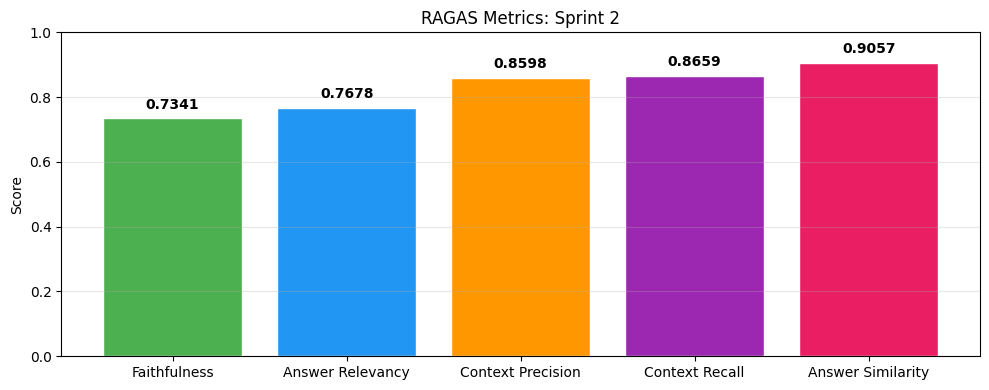

Saved RAGAS metrics chart to evaluations/sprint2_ragas_metrics.png


In [22]:
# ── Visualise Sprint 2 RAGAS metric scores ──
metric_names = ["faithfulness", "answer_relevancy", "context_precision", "context_recall", "answer_similarity"]
metric_values = [scores.get(m, 0) for m in metric_names]
labels = [m.replace("_", " ").title() for m in metric_names]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, metric_values,
              color=["#4CAF50", "#2196F3", "#FF9800", "#9C27B0", "#E91E63"], edgecolor="white")
ax.set_ylabel("Score")
ax.set_title("RAGAS Metrics: Sprint 2")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.02,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(project_root, "evaluations", "sprint2_ragas_metrics.png"), dpi=150)
plt.show()
print("Saved RAGAS metrics chart to evaluations/sprint2_ragas_metrics.png")

### 8.3 - Latency Metrics

Latency Statistics (seconds):
       retrieval_time_s  generation_time_s  total_time_s
count          100.0000           100.0000      100.0000
mean             0.2865            20.7503       21.0369
std              0.1149             6.3375        6.3421
min              0.1887            11.1849       11.4333
25%              0.2387            16.2567       16.5240
50%              0.2508            19.2706       19.5512
75%              0.2782            24.4798       24.7144
max              0.8793            45.4454       45.7094


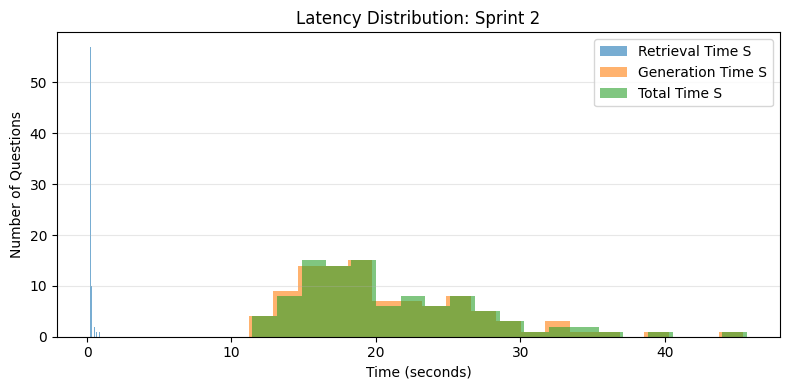

Saved latency chart to evaluations/sprint2_latency.png


In [23]:
# ── Display latency summary statistics ──
latency_cols = ["retrieval_time_s", "generation_time_s", "total_time_s"]
available_cols = [c for c in latency_cols if c in results_df.columns]

if available_cols:
    latency_stats = results_df[available_cols].describe().round(4)
    print("Latency Statistics (seconds):")
    print(latency_stats.to_string())

    # Latency distribution plot
    fig, ax = plt.subplots(figsize=(8, 4))
    for col in available_cols:
        ax.hist(results_df[col], bins=20, alpha=0.6, label=col.replace("_", " ").title())
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Number of Questions")
    ax.set_title("Latency Distribution: Sprint 2")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, "evaluations", "sprint2_latency.png"), dpi=150)
    plt.show()
    print("Saved latency chart to evaluations/sprint2_latency.png")
else:
    print("No latency data available.")

### 8.4 - Scores by Question Category

Break down RAGAS metrics by evaluation question difficulty (easy, medium, hard, very_hard, out_of_scope). This shows where the Sprint 2 improvements have the most impact.

RAGAS Scores by Question Category:
              faithfulness  answer_relevancy  context_precision  context_recall  answer_similarity
category                                                                                          
easy                0.7847            0.8515             0.9596          0.8970             0.9242
hard                0.6398            0.8286             0.9187          0.8803             0.8957
medium              0.8373            0.8580             0.9391          0.9185             0.8871
out_of_scope        0.2222            0.0000             0.0806          0.5500             1.0000
very_hard           0.9223            0.9096             0.9837          0.9083             0.8315

Questions per category: {'easy': 30, 'medium': 30, 'hard': 20, 'very_hard': 10, 'out_of_scope': 10}


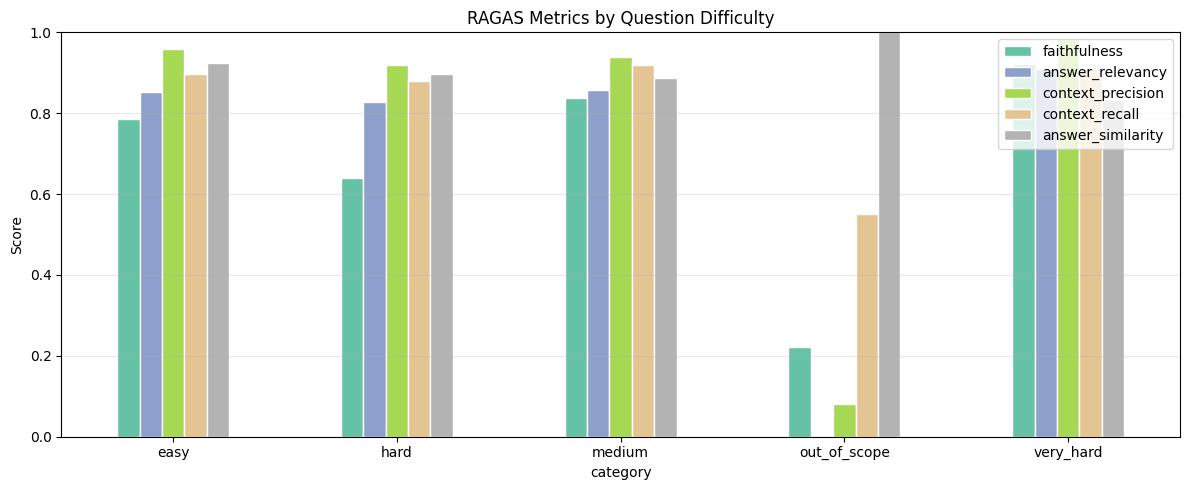

Saved category breakdown to evaluations/sprint2_category_breakdown.png


In [24]:
# ── Per-category RAGAS breakdown ──
# Merge category from eval_dataset into results
categories = [item.get("category", "unknown") for item in eval_dataset]
if len(categories) == len(results_df):
    results_df["category"] = categories

    metric_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall", "answer_similarity"]
    available_metrics = [c for c in metric_cols if c in results_df.columns]

    category_scores = results_df.groupby("category")[available_metrics].mean().round(4)
    category_counts = results_df["category"].value_counts()

    print("RAGAS Scores by Question Category:")
    print(category_scores.to_string())
    print(f"\nQuestions per category: {category_counts.to_dict()}")

    # Grouped bar chart by category
    fig, ax = plt.subplots(figsize=(12, 5))
    category_scores.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white")
    ax.set_ylabel("Score")
    ax.set_title("RAGAS Metrics by Question Difficulty")
    ax.set_ylim(0, 1.0)
    ax.legend(loc="lower right")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, "evaluations", "sprint2_category_breakdown.png"), dpi=150)
    plt.show()
    print("Saved category breakdown to evaluations/sprint2_category_breakdown.png")
else:
    print("Category count mismatch, skipping breakdown.")

### 8.5 - In-Scope vs Out-of-Scope Analysis

This section separates evaluation results into three views to demonstrate how OOS questions affect overall metrics:
1. **All 100 Questions** — Complete system evaluation
2. **In-Scope (90 Questions)** — RAG pipeline quality for answerable questions
3. **Out-of-Scope (10 Questions)** — Refusal quality measured via `answer_similarity`

Standard RAGAS metrics (faithfulness, answer_relevancy, context_precision, context_recall) are designed for in-scope Q&A. For OOS questions where the system correctly refuses, these metrics produce low scores because the refusal does not match the context. The `answer_similarity` metric, which compares the generated answer to ground truth using embeddings, is the appropriate metric for measuring refusal quality.

RAGAS METRICS: ALL vs IN-SCOPE vs OUT-OF-SCOPE
           Metric All (100) In-Scope (90) OOS (10)
     Faithfulness    0.7341        0.7853   0.2222
 Answer Relevancy    0.7678        0.8550   0.0000
Context Precision    0.8598        0.9464   0.0806
   Context Recall    0.8659        0.9018   0.5500
Answer Similarity    0.9057        0.8952   1.0000



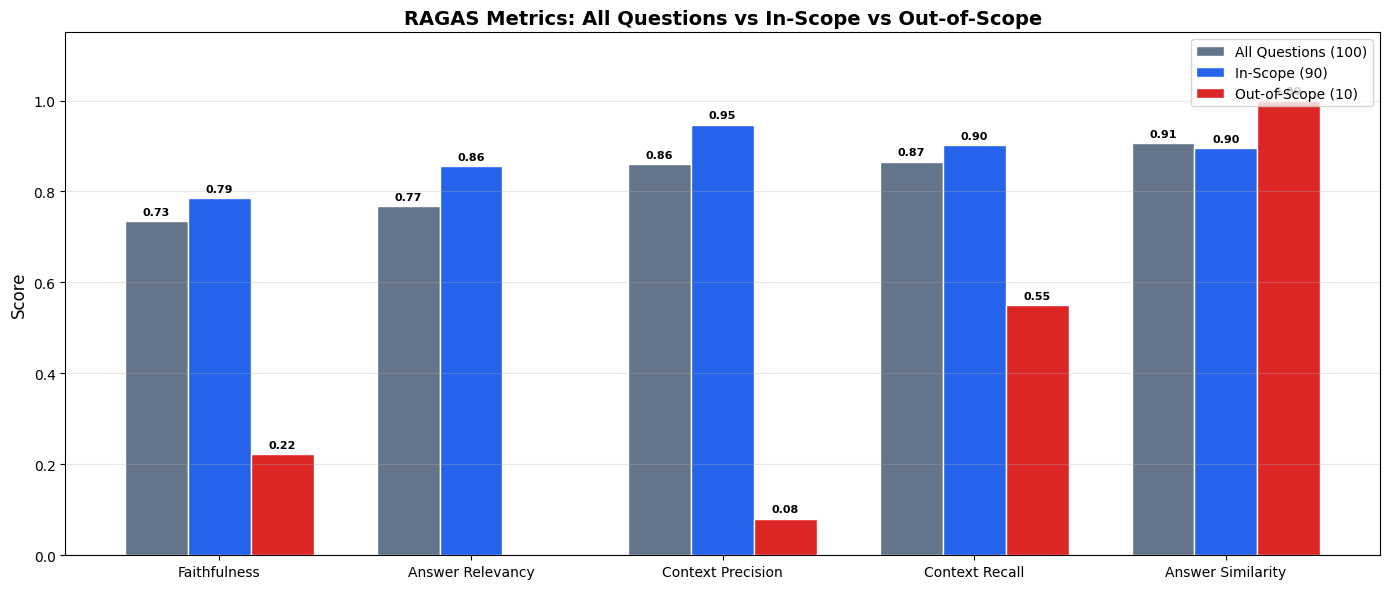

Saved to evaluations/sprint2_inscope_vs_oos.png


In [25]:
# ── In-Scope vs OOS Analysis ──
import numpy as np

metric_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall", "answer_similarity"]
available = [c for c in metric_cols if c in results_df.columns]

# Split results by category
in_scope_df = results_df[results_df["category"] != "out_of_scope"]
oos_df = results_df[results_df["category"] == "out_of_scope"]

# Calculate averages for each view
all_avg = results_df[available].mean()
inscope_avg = in_scope_df[available].mean()
oos_avg = oos_df[available].mean()

# ── Summary Table ──
summary_df = pd.DataFrame({
    "Metric": [m.replace("_", " ").title() for m in available],
    f"All ({len(results_df)})": [f"{all_avg[m]:.4f}" for m in available],
    f"In-Scope ({len(in_scope_df)})": [f"{inscope_avg[m]:.4f}" for m in available],
    f"OOS ({len(oos_df)})": [f"{oos_avg[m]:.4f}" for m in available],
})
print("=" * 90)
print("RAGAS METRICS: ALL vs IN-SCOPE vs OUT-OF-SCOPE")
print("=" * 90)
print(summary_df.to_string(index=False))
print()

# ── Chart 1: Side-by-side grouped bar chart ──
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(available))
width = 0.25
labels = [m.replace("_", " ").title() for m in available]

bars1 = ax.bar(x - width, [all_avg[m] for m in available], width,
               label=f"All Questions ({len(results_df)})", color="#64748b", edgecolor="white")
bars2 = ax.bar(x, [inscope_avg[m] for m in available], width,
               label=f"In-Scope ({len(in_scope_df)})", color="#2563eb", edgecolor="white")
bars3 = ax.bar(x + width, [oos_avg[m] for m in available], width,
               label=f"Out-of-Scope ({len(oos_df)})", color="#dc2626", edgecolor="white")

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_ylabel("Score", fontsize=12)
ax.set_title("RAGAS Metrics: All Questions vs In-Scope vs Out-of-Scope", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10, loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, "evaluations", "sprint2_inscope_vs_oos.png"), dpi=150)
plt.show()
print("Saved to evaluations/sprint2_inscope_vs_oos.png")


In-Scope rerank scores: mean=4.176, median=4.749
OOS rerank scores:      mean=-7.726, median=-8.730
Gap: 11.902 (higher = better separation)


/var/folders/x7/bzdftf1s1kb16rsvnyrhknn80000gn/T/ipykernel_9357/3425431776.py:21: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



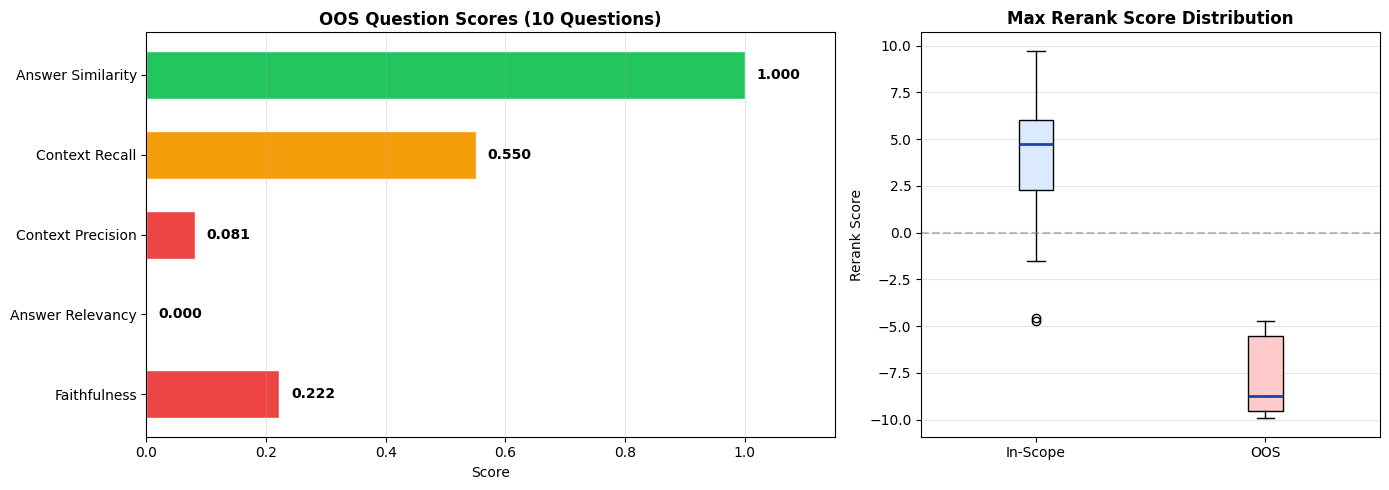

Saved to evaluations/sprint2_oos_detail.png


In [26]:
# ── Chart 2: OOS Refusal Quality Detail ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [3, 2]})

# Left: OOS per-metric scores
oos_values = [oos_avg[m] for m in available]
colors = ["#ef4444" if v < 0.3 else "#f59e0b" if v < 0.7 else "#22c55e" for v in oos_values]
bars = ax1.barh(labels, oos_values, color=colors, edgecolor="white", height=0.6)
for bar, val in zip(bars, oos_values):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=10, fontweight="bold")
ax1.set_xlim(0, 1.15)
ax1.set_title("OOS Question Scores (10 Questions)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Score")
ax1.grid(axis="x", alpha=0.3)

# Right: Rerank score distribution for OOS vs In-Scope
if "max_rerank_score" in results_df.columns:
    inscope_rerank = in_scope_df["max_rerank_score"].dropna()
    oos_rerank = oos_df["max_rerank_score"].dropna()
    data_to_plot = [inscope_rerank.values, oos_rerank.values]
    bp = ax2.boxplot(data_to_plot, labels=["In-Scope", "OOS"], patch_artist=True,
                     boxprops=dict(facecolor="#dbeafe"), medianprops=dict(color="#1e40af", linewidth=2))
    bp["boxes"][1].set_facecolor("#fecaca")
    ax2.set_title("Max Rerank Score Distribution", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Rerank Score")
    ax2.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    ax2.grid(axis="y", alpha=0.3)
    
    # Print stats
    print(f"In-Scope rerank scores: mean={inscope_rerank.mean():.3f}, median={inscope_rerank.median():.3f}")
    print(f"OOS rerank scores:      mean={oos_rerank.mean():.3f}, median={oos_rerank.median():.3f}")
    print(f"Gap: {inscope_rerank.mean() - oos_rerank.mean():.3f} (higher = better separation)")

plt.tight_layout()
plt.savefig(os.path.join(project_root, "evaluations", "sprint2_oos_detail.png"), dpi=150)
plt.show()
print("Saved to evaluations/sprint2_oos_detail.png")


In [27]:
# ── OOS Impact Analysis: How much do OOS questions drag down overall scores? ──
print("=" * 90)
print("OOS IMPACT ANALYSIS")
print("=" * 90)

impact_data = []
for m in available:
    all_score = all_avg[m]
    is_score = inscope_avg[m]
    oos_score = oos_avg[m]
    drag = is_score - all_score  # How much OOS drags down the overall
    impact_data.append({
        "Metric": m.replace("_", " ").title(),
        "Overall": f"{all_score:.4f}",
        "In-Scope": f"{is_score:.4f}",
        "OOS": f"{oos_score:.4f}",
        "OOS Drag": f"{drag:+.4f}",
        "OOS Appropriate?": "✓ answer_similarity" if m in ["answer_similarity"] else "✗ designed for in-scope",
    })

impact_df = pd.DataFrame(impact_data)
print(impact_df.to_string(index=False))
print()
print("Key: OOS Drag = In-Scope score minus Overall score (positive = OOS questions drag overall down)")
print(f"\n  → Without OOS questions, the RAG pipeline scores {inscope_avg.mean():.4f} avg across all metrics")
print(f"  → With OOS questions included, the overall average drops to {all_avg.mean():.4f}")
print(f"  → OOS refusal quality (answer_similarity) = {oos_avg.get('answer_similarity', 0):.4f}")


OOS IMPACT ANALYSIS
           Metric Overall In-Scope    OOS OOS Drag        OOS Appropriate?
     Faithfulness  0.7341   0.7853 0.2222  +0.0512 ✗ designed for in-scope
 Answer Relevancy  0.7678   0.8550 0.0000  +0.0872 ✗ designed for in-scope
Context Precision  0.8598   0.9464 0.0806  +0.0866 ✗ designed for in-scope
   Context Recall  0.8659   0.9018 0.5500  +0.0359 ✗ designed for in-scope
Answer Similarity  0.9057   0.8952 1.0000  -0.0105     ✓ answer_similarity

Key: OOS Drag = In-Scope score minus Overall score (positive = OOS questions drag overall down)

  → Without OOS questions, the RAG pipeline scores 0.8767 avg across all metrics
  → With OOS questions included, the overall average drops to 0.8267
  → OOS refusal quality (answer_similarity) = 1.0000


## 9 - Sprint 1 vs Sprint 2 Comparison

           Metric  Sprint 1 (Baseline)  Sprint 2 (Actual)  Sprint 2 Target    Delta  Target Met
     faithfulness               0.6834           0.734135             0.75 0.050735       False
 answer_relevancy               0.7216           0.767777             0.75 0.046177        True
context_precision               0.7885           0.859792             0.80 0.071292        True
   context_recall               0.8224           0.865898             0.85 0.043498        True
answer_similarity               0.0000           0.905702             0.80 0.905702        True


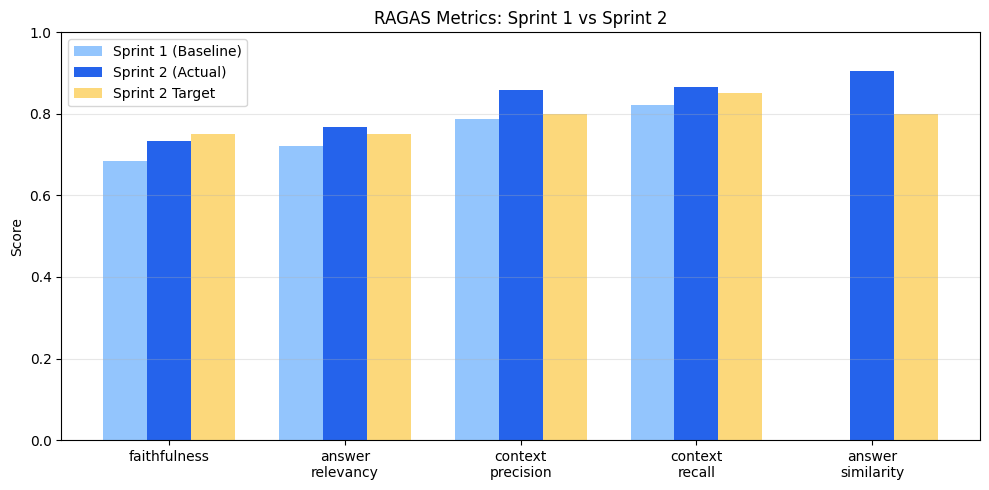

Saved comparison chart to evaluations/sprint2_comparison.png


In [28]:
import matplotlib.pyplot as plt

# Sprint 1 baseline scores (from eval_results.csv / Sprint 1 notebook)
sprint1_scores = {
    "faithfulness": 0.6834,
    "answer_relevancy": 0.7216,
    "context_precision": 0.7885,
    "context_recall": 0.8224,
    "answer_similarity": 0.0,  # Not measured in Sprint 1
}

# Sprint 2 targets
sprint2_targets = {
    "faithfulness": 0.75,
    "answer_relevancy": 0.75,
    "context_precision": 0.80,
    "context_recall": 0.85,
    "answer_similarity": 0.80,  # New metric in Sprint 2
}

# Build comparison table
comparison = pd.DataFrame({
    "Metric": list(sprint1_scores.keys()),
    "Sprint 1 (Baseline)": list(sprint1_scores.values()),
    "Sprint 2 (Actual)": [scores.get(m, 0) for m in sprint1_scores.keys()],
    "Sprint 2 Target": list(sprint2_targets.values()),
})
comparison["Delta"] = comparison["Sprint 2 (Actual)"] - comparison["Sprint 1 (Baseline)"]
comparison["Target Met"] = comparison["Sprint 2 (Actual)"] >= comparison["Sprint 2 Target"]
print(comparison.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(sprint1_scores))
width = 0.25
metrics = list(sprint1_scores.keys())

bars1 = ax.bar([i - width for i in x], list(sprint1_scores.values()), width, label="Sprint 1 (Baseline)", color="#93c5fd")
bars2 = ax.bar(x, [scores.get(m, 0) for m in metrics], width, label="Sprint 2 (Actual)", color="#2563eb")
bars3 = ax.bar([i + width for i in x], list(sprint2_targets.values()), width, label="Sprint 2 Target", color="#fbbf24", alpha=0.6)

ax.set_ylabel("Score")
ax.set_title("RAGAS Metrics: Sprint 1 vs Sprint 2")
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", "\n") for m in metrics])
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, "evaluations", "sprint2_comparison.png"), dpi=150)
plt.show()
print("Saved comparison chart to evaluations/sprint2_comparison.png")

## 10 - ClearML Logging and Save Results

In [29]:
# ── Log evaluation metrics, parameters, results, and sample Q&A to ClearML ──
from src.config import EVAL_LLM_PROVIDER, EVAL_LLM_MODEL
from src.evaluation import log_metrics_to_clearml

# Extract numeric metrics only
numeric_metrics = {k: v for k, v in scores.items() if isinstance(v, (int, float))}

log_metrics_to_clearml(
    metrics=numeric_metrics,
    params={
        "sprint": 2,
        "chunking_strategy": "ISM-aware (control boundary detection)",
        "chunk_min_words": CHUNK_MIN_WORDS,
        "chunk_max_words": CHUNK_MAX_WORDS,
        "embedding_model": EMBEDDING_MODEL_NAME,
        "embedding_dimension": 768,
        "llm_provider": LLM_PROVIDER,
        "llm_model": LLM_MODEL_NAME,
        "eval_llm_provider": EVAL_LLM_PROVIDER,
        "eval_llm_model": EVAL_LLM_MODEL,
        "retrieval_method": "hybrid (vector + BM25 + RRF)",
        "initial_retrieve_count": INITIAL_RETRIEVE_COUNT,
        "rrf_k": RRF_K,
        "reranker_model": RERANKER_MODEL,
        "rerank_top_k": RERANK_TOP_K,
        "num_eval_questions": len(eval_dataset),
        "num_chunks_in_db": count_rows(supabase),
    },
    results_df=results_df,
    eval_results=eval_results,
)

# ── Upload CSV artifacts to ClearML ──
# results_df is already uploaded by log_metrics_to_clearml as "eval_results"
# Now upload the additional CSVs as separate artifacts
task.upload_artifact(name="sprint_comparison", artifact_object=comparison)
print("  Uploaded artifact: sprint_comparison (Sprint 1 vs Sprint 2 table)")

task.upload_artifact(name="chunk_statistics", artifact_object=chunk_df.drop(columns=["content"]))
print("  Uploaded artifact: chunk_statistics (per-chunk metadata and word counts)")

if "category" in results_df.columns:
    task.upload_artifact(name="category_breakdown", artifact_object=category_scores.reset_index())
    print("  Uploaded artifact: category_breakdown (RAGAS by question difficulty)")

# ── Upload all generated charts as images to ClearML ──
logger = task.get_logger()
chart_files = {
    "Sprint 2 RAGAS Metrics": "sprint2_ragas_metrics.png",
    "Sprint 1 vs Sprint 2 Comparison": "sprint2_comparison.png",
    "Chunk Size Distribution": "sprint2_chunk_analysis.png",
    "Metadata Coverage": "sprint2_metadata_coverage.png",
    "Latency Distribution": "sprint2_latency.png",
    "Category Breakdown": "sprint2_category_breakdown.png",
    "In-Scope vs OOS": "sprint2_inscope_vs_oos.png",
    "OOS Refusal Detail": "sprint2_oos_detail.png",
}

eval_dir = os.path.join(project_root, "evaluations")
for title, filename in chart_files.items():
    filepath = os.path.join(eval_dir, filename)
    if os.path.exists(filepath):
        logger.report_image(title=title, series="Charts", local_path=filepath, iteration=0)
        print(f"  Uploaded chart: {title}")

# ── Upload tables to ClearML Plots tab ──
logger.report_table(
    title="Sprint Comparison",
    series="Sprint 1 vs Sprint 2",
    table_plot=comparison,
)

if "category" in results_df.columns:
    logger.report_table(
        title="Category Breakdown",
        series="RAGAS by Question Difficulty",
        table_plot=category_scores.reset_index(),
    )

# ── Upload In-Scope vs OOS summary table ──
if "category" in results_df.columns:
    oos_impact_table = pd.DataFrame({
        "Metric": [m.replace("_", " ").title() for m in available],
        "All Questions": [results_df[m].mean() for m in available],
        "In-Scope": [in_scope_df[m].mean() for m in available] if len(in_scope_df) > 0 else [0]*len(available),
        "Out-of-Scope": [oos_df[m].mean() for m in available] if len(oos_df) > 0 else [0]*len(available),
    })
    logger.report_table(
        title="In-Scope vs OOS Analysis",
        series="Metric Comparison",
        table_plot=oos_impact_table,
    )
    task.upload_artifact(name="inscope_vs_oos", artifact_object=oos_impact_table)
    print("  Uploaded table: In-Scope vs OOS Analysis")

print("\nAll metrics, parameters, charts, CSVs, and results logged to ClearML.")

Uploaded eval_results artifact (100 rows).
Logged 10 sample Q&A outputs to ClearML.
Logged 9 metrics to ClearML.
  Uploaded artifact: sprint_comparison (Sprint 1 vs Sprint 2 table)
  Uploaded artifact: chunk_statistics (per-chunk metadata and word counts)
  Uploaded artifact: category_breakdown (RAGAS by question difficulty)
  Uploaded chart: Sprint 2 RAGAS Metrics
  Uploaded chart: Sprint 1 vs Sprint 2 Comparison
  Uploaded chart: Chunk Size Distribution
  Uploaded chart: Metadata Coverage
  Uploaded chart: Latency Distribution
  Uploaded chart: Category Breakdown
  Uploaded chart: In-Scope vs OOS
  Uploaded chart: OOS Refusal Detail
  Uploaded table: In-Scope vs OOS Analysis

All metrics, parameters, charts, CSVs, and results logged to ClearML.


### 10.1 - Save Evaluation Results

In [30]:
# ── Save evaluation results to CSV ──
results_path = os.path.join(project_root, "evaluations", "sprint2_eval_results.csv")
results_df.to_csv(results_path, index=False)
print(f"Saved {len(results_df)} rows to {results_path}")

# Also save the comparison table
comparison_path = os.path.join(project_root, "evaluations", "sprint2_vs_sprint1.csv")
comparison.to_csv(comparison_path, index=False)
print(f"Saved sprint comparison to {comparison_path}")

Saved 100 rows to /Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/evaluations/sprint2_eval_results.csv
Saved sprint comparison to /Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/evaluations/sprint2_vs_sprint1.csv


---
## 11 - Close ClearML Task

In [31]:
# ── Terminate and mark the current ClearML tracking task as completed ──
from clearml import Task

current_task = Task.current_task()
if current_task:
    current_task.close()
    print("ClearML task successfully closed and marked as 'Completed'.")
else:
    print("No active ClearML task found.")

ClearML task successfully closed and marked as 'Completed'.
